<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [1]:
# !wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
!curl -O https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0  201M    0  6640    0     0   3760      0 15:37:07  0:00:01 15:37:06  3764
  0  201M    0  109k    0     0  41893      0  1:24:06  0:00:02  1:24:04 41919
  0  201M    0  821k    0     0   222k      0  0:15:29  0:00:03  0:15:26  222k
  0  201M    0 1820k    0     0   389k      0  0:08:50  0:00:04  0:08:46  389k
  1  201M    1 3248k    0     0   571k      0  0:06:00  0:00:05  0:05:55  675k
  2  201M    2 4766k    0     0   713k      0  0:04:49  0:00:06  0:04:43  968k
  3  201M    3 6377k    0     0   830k      0  0:04:08  0:00:07  0:04:01 1255k
  3  201M    3 7995k    0     0   920k      0  0:03:44  0:00:08  0:03:36 1439k
  4  201M    4 9618k    0     0   993k      0  0:03

#### 2. Connect to the Database


**Install the needed libraries**


In [2]:
# !pip install pandas

In [3]:
# !pip install matplotlib

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [5]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)

   COUNT(*)
0     65437


#### Demo 2: List All Tables


In [6]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [7]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


In [8]:
# your code goes here
query = '''
SELECT CompTotal
FROM main
WHERE CompTotal IS NOT NULL
'''
df_comp = pd.read_sql_query(query, conn)
df_comp

,CompTotal
0,2040000.0
1,28000.0
2,85000.0
3,50000.0
4,110000.0
...,...
33735,36000.0
33736,40000.0
33737,61000.0
33738,58000.0


In [9]:
q1 = df_comp['CompTotal'].quantile(0.25)
q3 = df_comp['CompTotal'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)

In [10]:
df_comp_fil = df_comp[(df_comp['CompTotal'] >= lower_bound) & (df_comp['CompTotal'] <= upper_bound)]

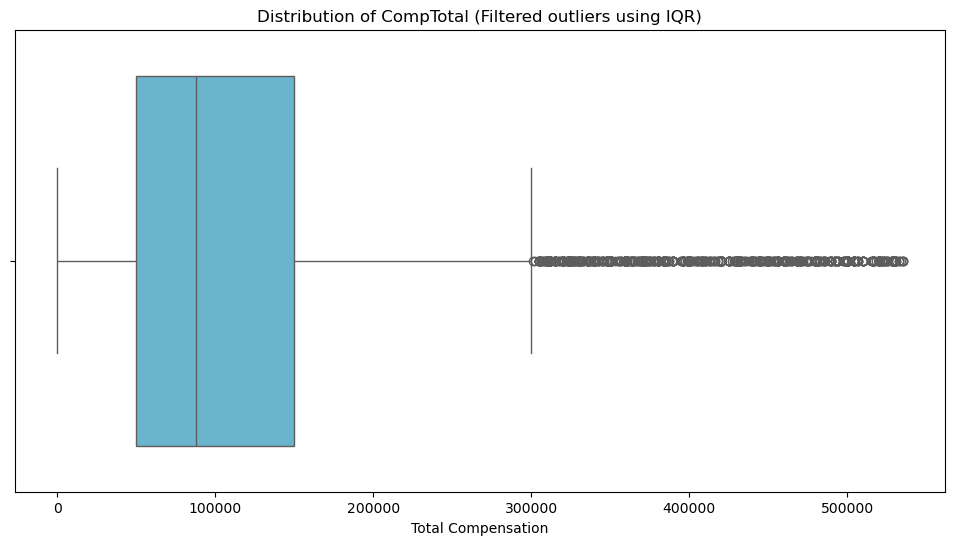

In [11]:
plt.figure(figsize = (12, 6))
sns.boxplot(x = df_comp_fil['CompTotal'], color = '#5abedd')
plt.xlabel('Total Compensation')
plt.title('Distribution of CompTotal (Filtered outliers using IQR)')
plt.show()

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


In [12]:
# your code goes here
query = '''
SELECT
    CASE
        WHEN Age = 'Under 18 years old' THEN 15
        WHEN Age = '18-24 years old' THEN 21
        WHEN Age = '25-34 years old' THEN 29.5
        WHEN Age = '35-44 years old' THEN 39.5
        WHEN Age = '45-54 years old' THEN 49.5
        WHEN Age = '55-64 years old' THEN 59.5
        WHEN Age = '65 years or older' THEN 70
        ELSE NULL
    END AS Age_numeric
FROM main
WHERE Age_numeric IS NOT NULL
'''
df_age = pd.read_sql_query(query, conn)
df_age

,Age_numeric
0,15.0
1,39.5
2,49.5
3,21.0
4,21.0
...,...
65110,21.0
65111,29.5
65112,29.5
65113,21.0


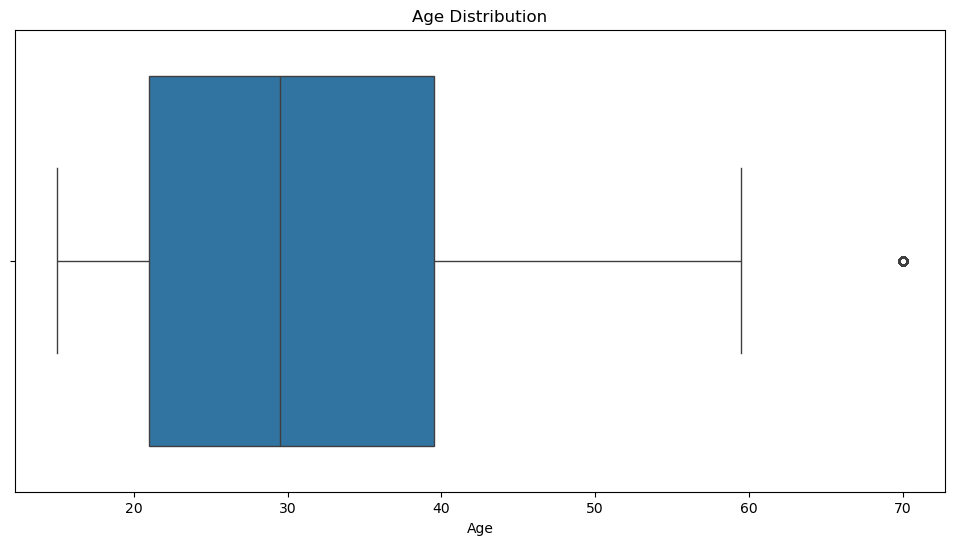

In [13]:
plt.figure(figsize = (12, 6))
sns.boxplot(x = df_age['Age_numeric'])
plt.title('Age Distribution')
plt.xlabel('Age')
plt.show()

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


In [14]:
# your code goes here
query = '''
SELECT Age, CompTotal
FROM main
WHERE CompTotal IS NOT NULL
AND Age IS NOT NULL
'''
df_comp_age = pd.read_sql_query(query, conn)
df_comp_age

,Age,CompTotal
0,18-24 years old,2040000.0
1,25-34 years old,28000.0
2,35-44 years old,85000.0
3,35-44 years old,50000.0
4,25-34 years old,110000.0
...,...,...
33735,18-24 years old,36000.0
33736,25-34 years old,40000.0
33737,25-34 years old,61000.0
33738,35-44 years old,58000.0


In [15]:
upper = df_comp_age['CompTotal'].quantile(0.95)
df_comp_age_fil = df_comp_age[df_comp_age['CompTotal'] <= upper]

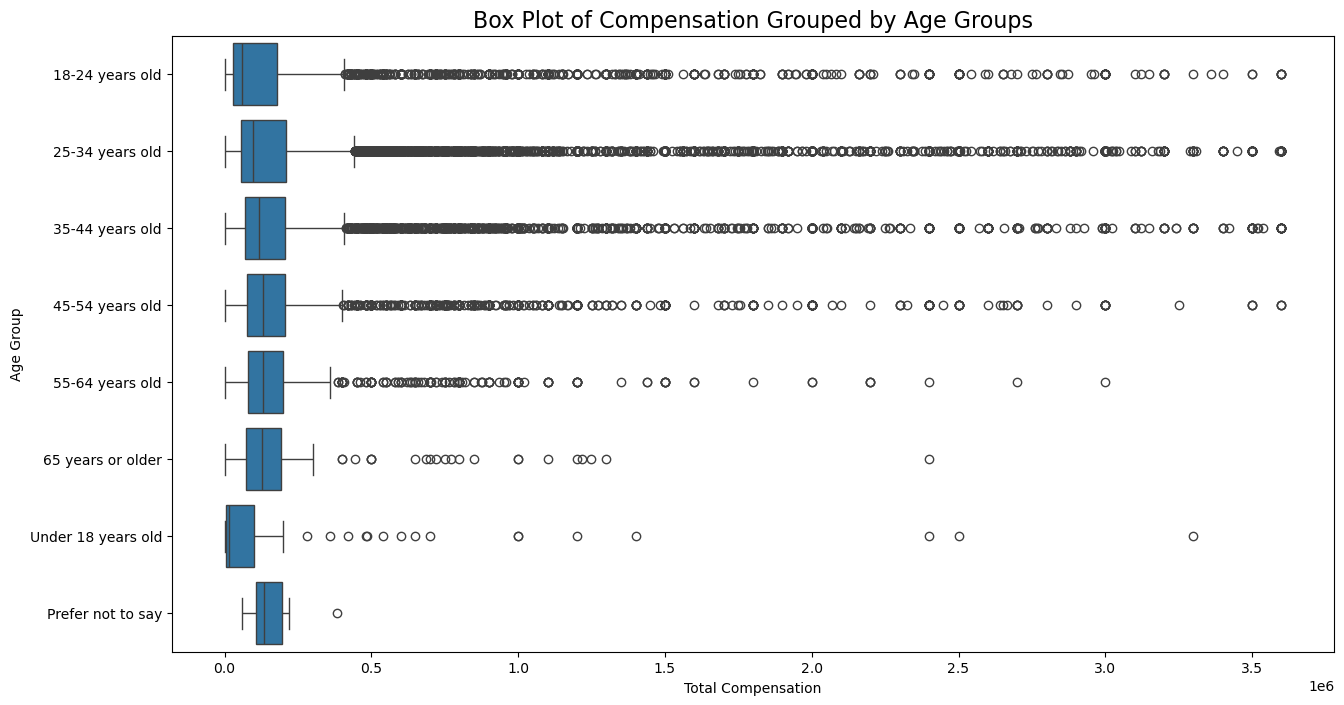

In [16]:
plt.figure(figsize = (15, 8))
sns.boxplot(data = df_comp_age_fil, x = 'CompTotal', y = 'Age')
plt.xlabel('Total Compensation')
plt.ylabel('Age Group')
plt.title('Box Plot of Compensation Grouped by Age Groups', fontsize = 16)
plt.show()

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


In [17]:
# your code goes here
query = '''
SELECT CompTotal, JobSatPoints_6
FROM main
WHERE CompTotal IS NOT NULL
AND JobSatPoints_6 IS NOT NULL
'''
df_comp_js6 = pd.read_sql_query(query, conn)
df_comp_js6

,CompTotal,JobSatPoints_6
0,2040000.0,65.0
1,85000.0,0.0
2,110000.0,20.0
3,126420.0,30.0
4,195000.0,30.0
...,...,...
22473,40000.0,20.0
22474,46000.0,50.0
22475,81600.0,20.0
22476,500000.0,0.0


In [18]:
upper_limit = df_comp_js6['CompTotal'].quantile(0.95)
df_comp_js6_fil = df_comp_js6[(df_comp_js6['CompTotal'] > 0) & (df_comp_js6['CompTotal'] <= upper_limit)]

In [19]:
bins = [0, 20, 40, 60, 80, 100]
labels = ['0-20', '21-40', '41-60', '61-80', '81-100']
df_comp_js6_fil['Satisfaction_Group'] = pd.cut(df_comp_js6_fil['JobSatPoints_6'], bins = bins, labels = labels, include_lowest = True)

C:\Users\MSI\AppData\Local\Temp\ipykernel_7652\184916049.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_comp_js6_fil['Satisfaction_Group'] = pd.cut(df_comp_js6_fil['JobSatPoints_6'], bins = bins, labels = labels, include_lowest = True)


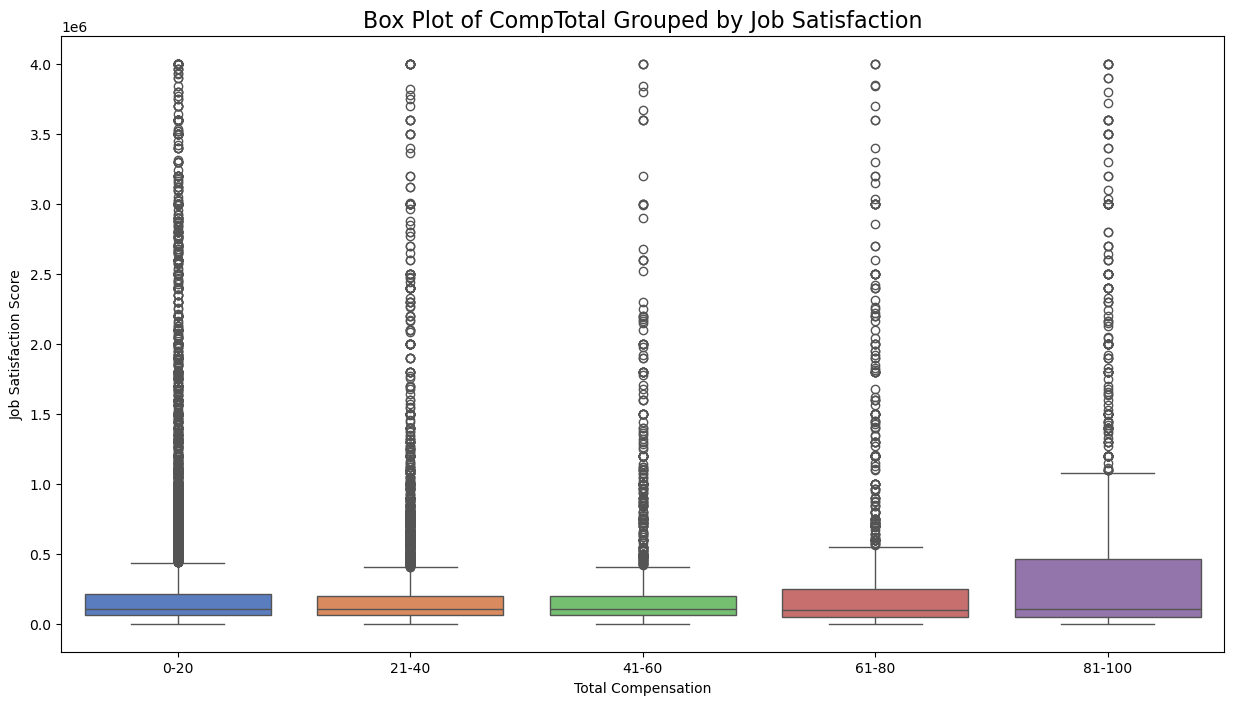

In [20]:
plt.figure(figsize=(15, 8))
sns.boxplot(data = df_comp_js6_fil, x = 'Satisfaction_Group', y = 'CompTotal', hue = 'Satisfaction_Group', palette = 'muted')
plt.xlabel('Total Compensation')
plt.ylabel('Job Satisfaction Score')
plt.title('Box Plot of CompTotal Grouped by Job Satisfaction', fontsize = 16)
plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


In [21]:
# your code goes here
query = '''
SELECT ConvertedCompYearly, DevType
FROM main
WHERE ConvertedCompYearly IS NOT NULL
AND DevType IS NOT NULL
'''
df_con_dev = pd.read_sql_query(query, conn)
df_con_dev

,ConvertedCompYearly,DevType
0,7322.0,Data scientist or machine learning specialist
1,30074.0,Academic researcher
2,91295.0,Data scientist or machine learning specialist
3,53703.0,"Developer, back-end"
4,110000.0,Student
...,...,...
23398,44640.0,"Developer, embedded applications or devices"
23399,170000.0,Project manager
23400,116844.0,"Developer, full-stack"
23401,12000.0,"Developer, full-stack"


In [22]:
top_5_dev = df_con_dev['DevType'].value_counts().nlargest(5).index
df_top5 = df_con_dev[df_con_dev['DevType'].isin(top_5_dev)]

In [23]:
upper_limit = df_top5['ConvertedCompYearly'].quantile(0.95)
df_top5_final = df_top5[df_top5['ConvertedCompYearly'] <= upper_limit]

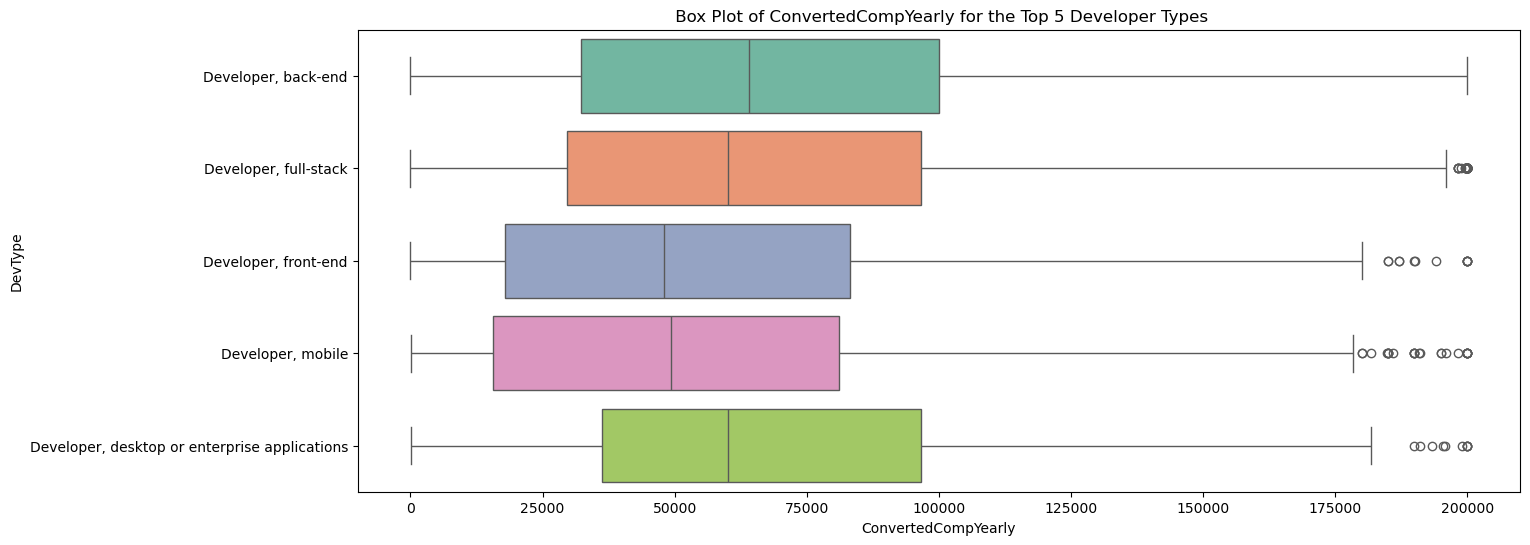

In [24]:
plt.figure(figsize=(15, 6))
sns.boxplot(data = df_top5_final, x = 'ConvertedCompYearly', y = 'DevType', hue = 'DevType', palette = 'Set2')
plt.title(' Box Plot of ConvertedCompYearly for the Top 5 Developer Types')
plt.show()

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


In [25]:
# your code goes here
query = '''
SELECT CompTotal, Country
FROM main
WHERE CompTotal IS NOT NULL 
AND Country IS NOT NULL
'''
df_comp_coun = pd.read_sql_query(query, conn)
df_comp_coun

,CompTotal,Country
0,2040000.0,Pakistan
1,28000.0,Austria
2,85000.0,Turkey
3,50000.0,France
4,110000.0,United States of America
...,...,...
33735,36000.0,Lithuania
33736,40000.0,France
33737,61000.0,France
33738,58000.0,Italy


In [26]:
top_5_countries = df_comp_coun['Country'].value_counts().nlargest(5).index
df_top5_coun = df_comp_coun[df_comp_coun['Country'].isin(top_5_countries)]

In [27]:
upper_limit = df_top5_coun['CompTotal'].quantile(0.95)
df_top5coun_final = df_top5_coun[df_top5_coun['CompTotal'] <= upper_limit]

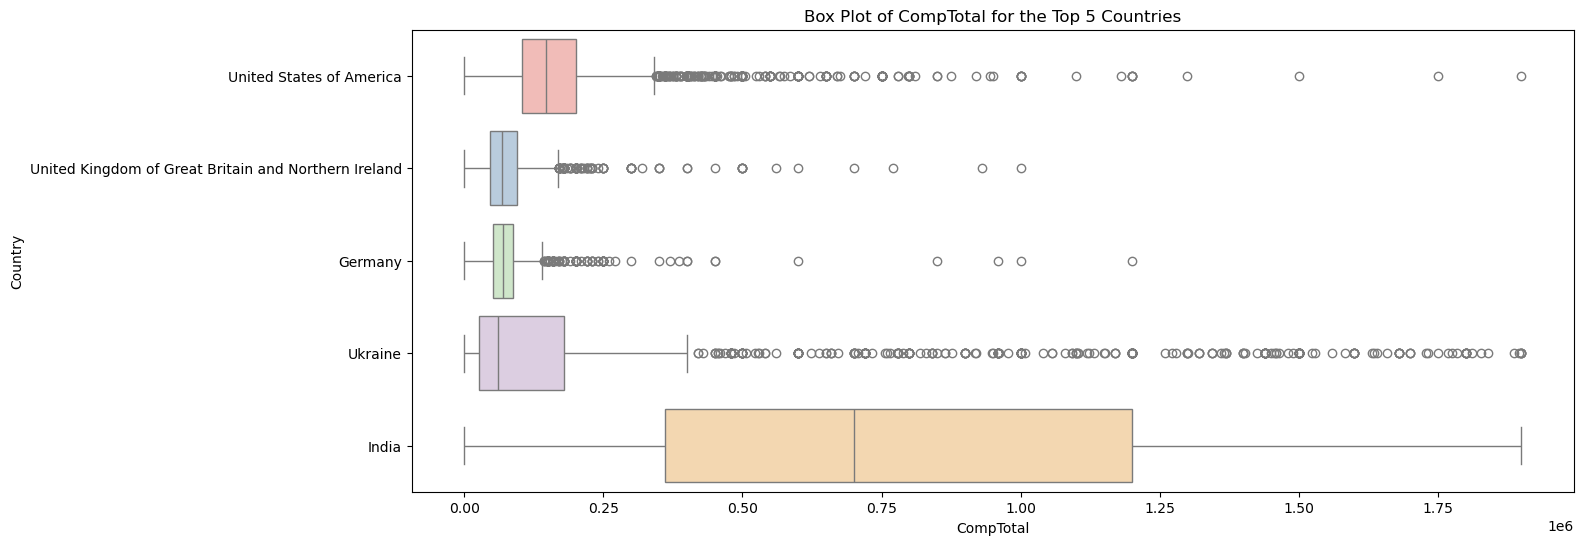

In [28]:
plt.figure(figsize = (15, 6))
sns.boxplot(data = df_top5coun_final, x = 'CompTotal', y = 'Country', hue = 'Country', palette = 'Pastel1')
plt.title('Box Plot of CompTotal for the Top 5 Countries')
plt.show()

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


In [29]:
# your code goes here
query = '''
SELECT CompTotal, Employment 
FROM main 
WHERE CompTotal IS NOT NULL 
AND Employment IS NOT NULL
'''
df_comp_emp = pd.read_sql_query(query, conn)
df_comp_emp

,CompTotal,Employment
0,2040000.0,"Employed, full-time;Student, full-time;Indepen..."
1,28000.0,"Employed, full-time"
2,85000.0,"Employed, full-time"
3,50000.0,"Independent contractor, freelancer, or self-em..."
4,110000.0,"Employed, full-time;Student, part-time"
...,...,...
33735,36000.0,"Employed, full-time;Independent contractor, fr..."
33736,40000.0,"Employed, full-time"
33737,61000.0,"Employed, full-time"
33738,58000.0,"Employed, full-time"


In [30]:
upper_limit = df_comp_emp['CompTotal'].quantile(0.95)
df_comp_final = df_comp_emp[df_comp_emp['CompTotal'] <= upper_limit]

In [31]:
df_comp_final['Employment'] = df_comp_final['Employment'].str[:45]

C:\Users\MSI\AppData\Local\Temp\ipykernel_7652\1575903318.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_comp_final['Employment'] = df_comp_final['Employment'].str[:45]


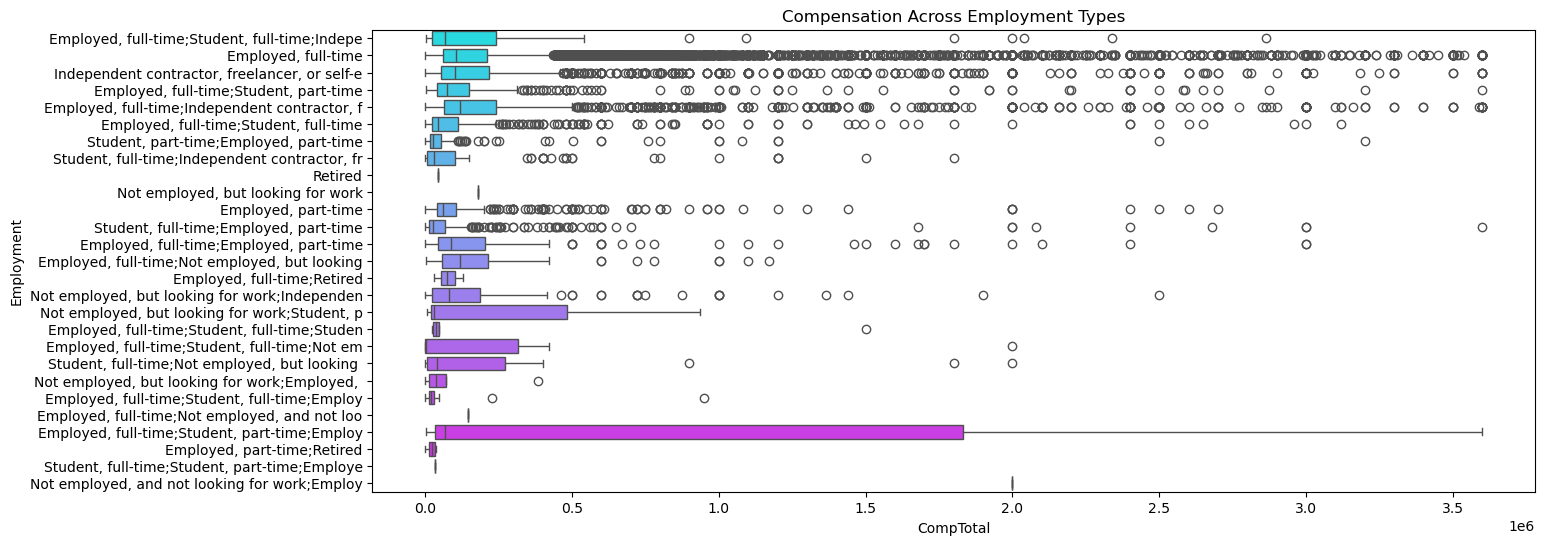

In [32]:
plt.figure(figsize=(15, 6))
sns.boxplot(data = df_comp_final, x = 'CompTotal', y = 'Employment', hue = 'Employment', palette = 'cool')
plt.title('Compensation Across Employment Types')
plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


In [33]:
# your code goes here
query = """
SELECT YearsCodePro, JobSatPoints_6 
FROM main 
WHERE YearsCodePro IS NOT NULL 
AND JobSatPoints_6 IS NOT NULL
"""
df_ycp_js6 = pd.read_sql_query(query, conn)
df_ycp_js6

,YearsCodePro,JobSatPoints_6
0,17,0.0
1,12,30.0
2,27,0.0
3,10,60.0
4,Less than 1 year,100.0
...,...,...
28614,2,0.0
28615,17,0.0
28616,2,60.0
28617,7,0.0


In [34]:
df_ycp_js6['YearsCodePro'] = df_ycp_js6['YearsCodePro'].replace({'Less than 1 year': 0, 'More than 50 years': 55})
df_ycp_js6['YearsCodePro'] = df_ycp_js6['YearsCodePro'].astype(float)

In [35]:
bins = [0, 20, 40, 60, 80, 100]
labels = ['0-20', '21-40', '41-60', '61-80', '81-100']
df_ycp_js6['Sat_Group'] = pd.cut(df_ycp_js6['JobSatPoints_6'], bins = bins, labels = labels, include_lowest = True)

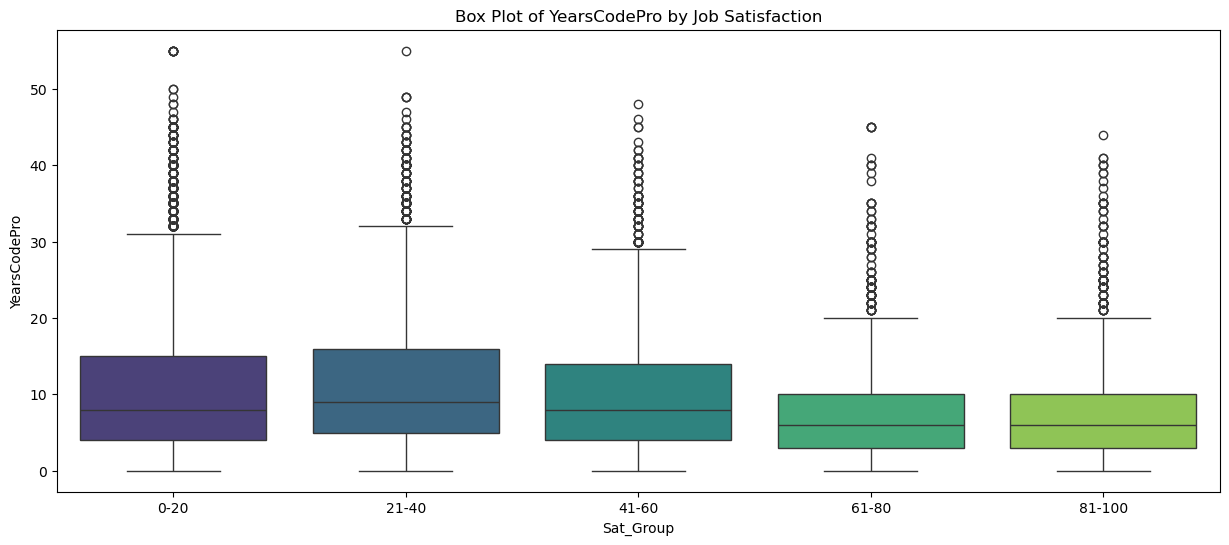

In [36]:
plt.figure(figsize=(15, 6))
sns.boxplot(data = df_ycp_js6, x = 'Sat_Group', y = 'YearsCodePro', hue = 'Sat_Group', palette = 'viridis')
plt.title('Box Plot of YearsCodePro by Job Satisfaction')
plt.show()

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [37]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
